# Day 2 — Convolutional Neural Networks (CNNs) with Training Tricks

**Phase 2 · Deep Learning Essentials · Day 2 / 3**

Yesterday we built an MLP for MNIST. Today we tackle a *much* harder problem with the right tool — a **Convolutional Neural Network**.

### Today's project
Train a CNN on **CIFAR-10** (60,000 small colour photos across 10 classes such as airplane, cat, dog, ship, truck, …) and use the modern training tricks that real practitioners rely on:
- **BatchNorm** for stable, fast training
- **Dropout** for regularisation
- **Data augmentation** for free extra data
- **Learning-rate scheduler** to fine-tune learning over time

### Why CNNs (not MLPs) for images?
- An MLP **flattens** the image and ignores spatial structure — pixel (5, 5) and (5, 6) are treated as unrelated.
- A CNN slides small **filters** across the image, sharing weights — it naturally learns *edges → textures → parts → objects*.
- CNNs have **far fewer parameters** than equivalent MLPs while being far more accurate on images.


## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__)
print("Device  :", device)

PyTorch : 2.9.1+cu128
Device  : cuda


## 2. How a convolutional layer works (intuition)

A conv layer slides a small **kernel** (e.g. 3×3) across the image. At every position it does an element-wise multiply with the local patch, sums the result, and writes it to the output.

```
Input image  ─►  [filter] slides across  ─►  Feature map
```

Key terms:
- **Kernel size** — how big each filter is (e.g. 3×3).
- **Stride** — how many pixels the filter jumps each step (1 = dense, 2 = halves the spatial size).
- **Padding** — adds zeros around the edge so the output stays the same size.
- **Channels** — input has 3 (RGB); each output channel is one *learned feature detector*.

A typical CNN block looks like:

```
Conv2d  →  BatchNorm  →  ReLU  →  MaxPool
```

Stacking blocks lets the network combine simple features (edges) into complex ones (whiskers, wheels, wings).


## 3. Dataset — CIFAR-10 with augmentation

CIFAR-10:
- 50,000 training + 10,000 test images
- Each image is **3 × 32 × 32** (RGB)
- 10 classes: `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

### Why augment?
By randomly flipping and cropping the training images, we effectively get *more data*, which makes the model more robust and reduces overfitting.

> **Important:** augmentation is applied **only to the training set**, never to the test set.


In [2]:
# Standard CIFAR-10 normalisation (per-channel mean and std)
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       # random crop with 4-pixel padding
    transforms.RandomHorizontalFlip(),          # 50% chance to flip left/right
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

CLASSES = ("plane","car","bird","cat","deer","dog","frog","horse","ship","truck")
print("Train:", len(train_dataset), " Test:", len(test_dataset))

100%|██████████| 170M/170M [01:57<00:00, 1.45MB/s] 


Train: 50000  Test: 10000


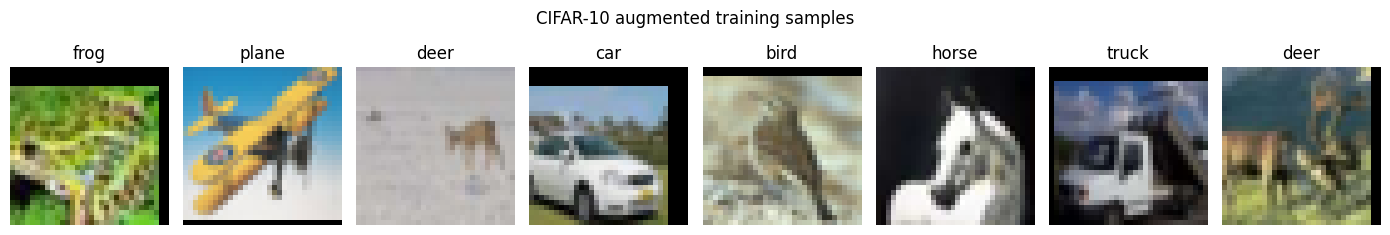

In [3]:
# Visualise a batch (un-normalising for display)
def denorm(img):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * STD[c] + MEAN[c]
    return img.clamp(0, 1)

loader_for_viz = DataLoader(train_dataset, batch_size=8, shuffle=True)
imgs, labels = next(iter(loader_for_viz))

fig, axes = plt.subplots(1, 8, figsize=(14, 2.5))
for ax, img, lab in zip(axes, imgs, labels):
    ax.imshow(denorm(img).permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[lab.item()])
    ax.axis("off")
plt.suptitle("CIFAR-10 augmented training samples")
plt.tight_layout()
plt.show()

In [4]:
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)   # [128, 3, 32, 32]

Batch shape: torch.Size([128, 3, 32, 32])


## 4. Building the CNN

We'll build a small but effective CNN with **three conv blocks** followed by **two fully-connected layers**.

```
Conv(3→32)  → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool   # 32x32 → 16x16
Conv(32→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool   # 16x16 → 8x8
Conv(64→128)→ BN → ReLU → Conv(128→128)→ BN → ReLU → MaxPool  # 8x8  → 4x4
Flatten → FC(128*4*4 → 256) → ReLU → Dropout(0.5) → FC(256 → 10)
```

### What each trick does
- **BatchNorm2d** — normalises activations within each mini-batch. Lets us use a higher learning rate and trains faster.
- **Dropout(0.5)** — randomly zeroes 50% of neurons during training only. Prevents the network from over-relying on any one neuron and reduces overfitting.
- **MaxPool2d** — keeps the strongest signal in each 2×2 region while halving spatial dimensions.


In [5]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # --- Block 1 ---
        self.conv1a = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32)
        self.pool1  = nn.MaxPool2d(2)

        # --- Block 2 ---
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)
        self.pool2  = nn.MaxPool2d(2)

        # --- Block 3 ---
        self.conv3a = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3a   = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3b   = nn.BatchNorm2d(128)
        self.pool3  = nn.MaxPool2d(2)

        # --- Classifier head ---
        self.fc1     = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.pool1(x)
        # Block 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.pool2(x)
        # Block 3
        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = self.pool3(x)
        # Head
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)        # raw logits
        return x

model = SmallCNN().to(device)
print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SmallCNN(
  (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, tra

In [6]:
# Sanity check: feed a dummy batch and confirm the output shape
dummy = torch.randn(2, 3, 32, 32).to(device)
out = model(dummy)
print("Input :", dummy.shape, "  Output:", out.shape)   # expect [2, 10]

Input : torch.Size([2, 3, 32, 32])   Output: torch.Size([2, 10])


## 5. Loss, optimizer and learning-rate scheduler

We add one new ingredient compared to Day 1: a **learning-rate scheduler**.

`StepLR(optimizer, step_size=10, gamma=0.5)` halves the learning rate every 10 epochs. Why?
- Early in training a *large* LR helps the model find a good region of weights.
- Later, a *smaller* LR helps it settle into the minimum without overshooting.

This pattern (start hot, cool down) consistently squeezes out an extra 1–3% accuracy.


In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 15

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

print("LR schedule: start", LEARNING_RATE, " — halve every 10 epochs")

LR schedule: start 0.001  — halve every 10 epochs


## 6. Training loop

Same five steps as Day 1, plus `scheduler.step()` once per epoch.


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total

In [9]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "lr": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "cifar10_cnn_best.pth")
        flag = "  <-- new best, saved"
    else:
        flag = ""

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"test_loss={te_loss:.4f} acc={te_acc:.4f} | "
          f"lr={optimizer.param_groups[0]['lr']:.5f}{flag}")

print(f"\nBest test accuracy: {best_acc:.4f}")

Epoch  1/15 | train_loss=1.4926 acc=0.4542 | test_loss=1.3335 acc=0.5377 | lr=0.00100  <-- new best, saved
Epoch  2/15 | train_loss=1.0813 acc=0.6183 | test_loss=0.9729 acc=0.6531 | lr=0.00100  <-- new best, saved
Epoch  3/15 | train_loss=0.9092 acc=0.6847 | test_loss=0.8358 acc=0.7029 | lr=0.00100  <-- new best, saved
Epoch  4/15 | train_loss=0.8173 acc=0.7175 | test_loss=0.7693 acc=0.7364 | lr=0.00100  <-- new best, saved
Epoch  5/15 | train_loss=0.7461 acc=0.7444 | test_loss=0.7791 acc=0.7299 | lr=0.00100
Epoch  6/15 | train_loss=0.6949 acc=0.7648 | test_loss=0.6746 acc=0.7676 | lr=0.00100  <-- new best, saved
Epoch  7/15 | train_loss=0.6466 acc=0.7844 | test_loss=0.7248 acc=0.7558 | lr=0.00100
Epoch  8/15 | train_loss=0.6071 acc=0.7973 | test_loss=0.6657 acc=0.7769 | lr=0.00100  <-- new best, saved
Epoch  9/15 | train_loss=0.5730 acc=0.8090 | test_loss=0.5685 acc=0.8084 | lr=0.00100  <-- new best, saved
Epoch 10/15 | train_loss=0.5473 acc=0.8164 | test_loss=0.8154 acc=0.7426 | lr=0

## 7. Visualise training

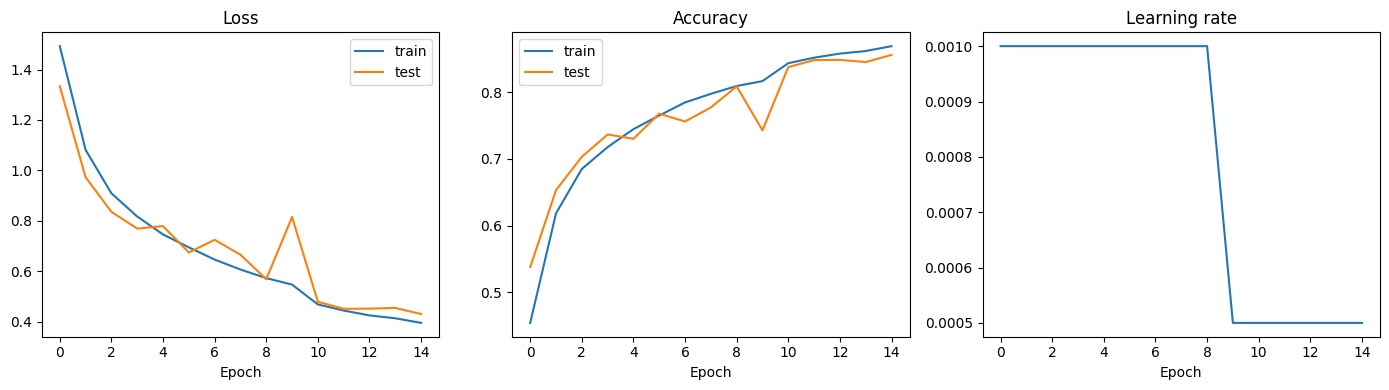

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"],  label="test")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"],  label="test")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history["lr"])
axes[2].set_title("Learning rate"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

### Reading the curves
- If **train accuracy** keeps rising but **test accuracy** stalls — the model is **overfitting**. Increase Dropout, add more augmentation, or train fewer epochs.
- If both rise together but slowly — the model has capacity left. Train longer or make the model bigger.
- A clear "step" each time the LR drops shows the scheduler is doing its job.


## 8. Confusion matrix on the test set

Which classes does the model still confuse? On CIFAR-10, **cat ↔ dog** and **deer ↔ horse** are notoriously hard.


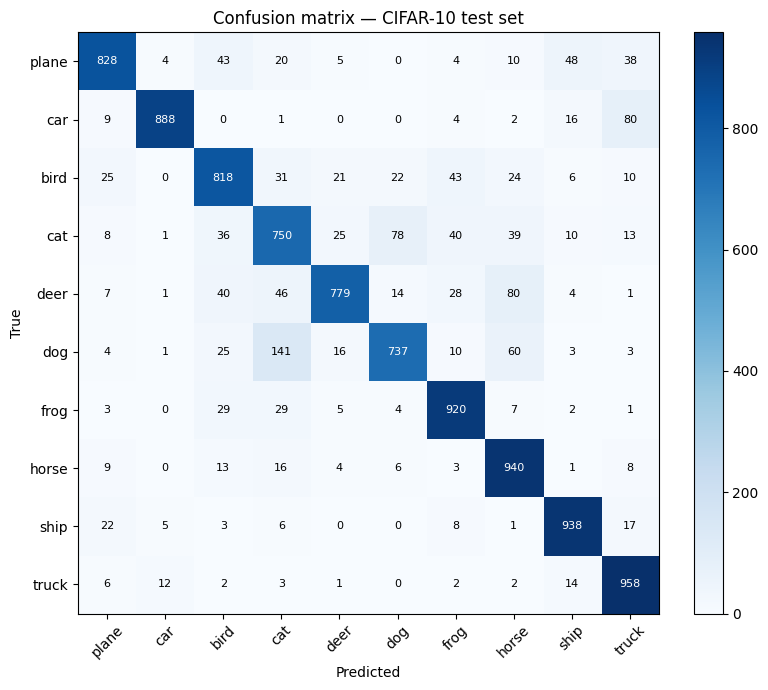


Per-class accuracy:
     plane: 0.828
       car: 0.888
      bird: 0.818
       cat: 0.750
      deer: 0.779
       dog: 0.737
      frog: 0.920
     horse: 0.940
      ship: 0.938
     truck: 0.958


In [11]:
# Reload the best checkpoint before evaluating
model.load_state_dict(torch.load("cifar10_cnn_best.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(labels)
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10), CLASSES, rotation=45)
ax.set_yticks(range(10), CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — CIFAR-10 test set")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(CLASSES):
    print(f"  {name:>8s}: {cm[i, i] / cm[i].sum():.3f}")

## 9. Look at sample predictions

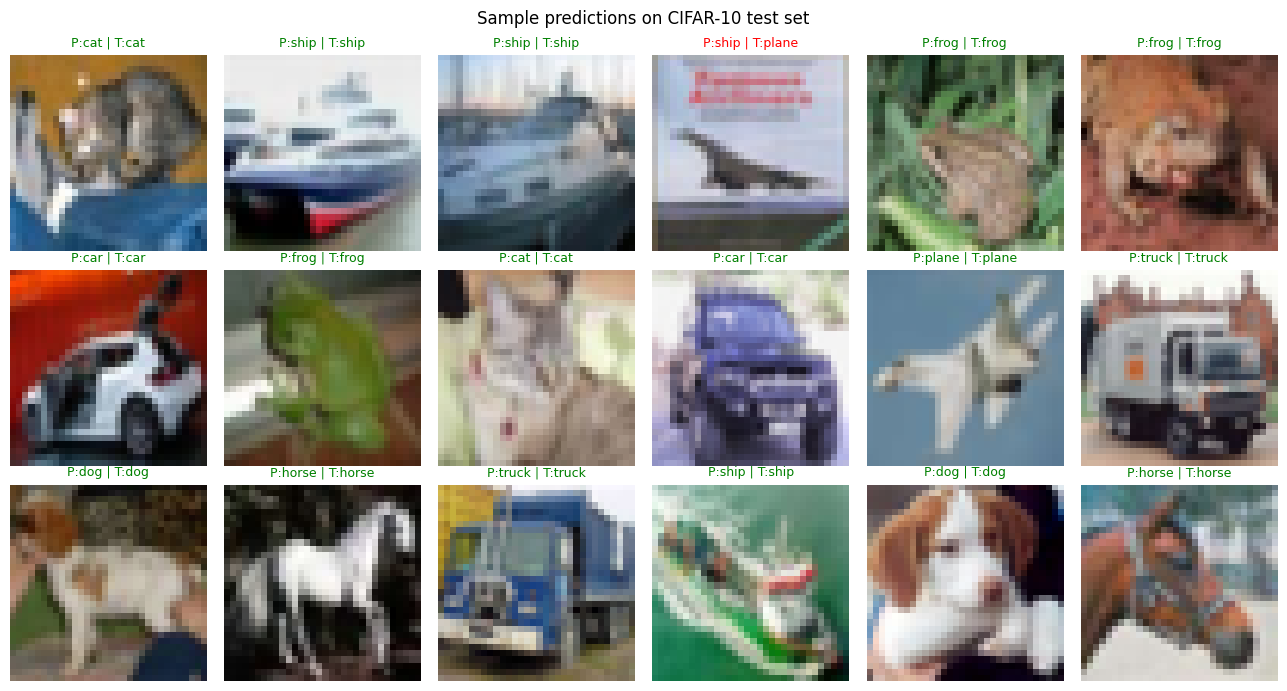

In [12]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for i, ax in enumerate(axes.flat):
    img = denorm(images[i].cpu()).permute(1, 2, 0).numpy()
    t, p = labels[i].item(), preds[i].item()
    ax.imshow(img)
    color = "green" if p == t else "red"
    ax.set_title(f"P:{CLASSES[p]} | T:{CLASSES[t]}", color=color, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample predictions on CIFAR-10 test set")
plt.tight_layout()
plt.show()

## 10. (Bonus) — Visualise what the first conv layer learned

Each filter in the very first conv layer is a 3×3×3 RGB kernel. Plotting them lets us peek at the low-level features the network discovered (often coloured edges and blobs).


Conv1 filter tensor shape: torch.Size([32, 3, 3, 3])


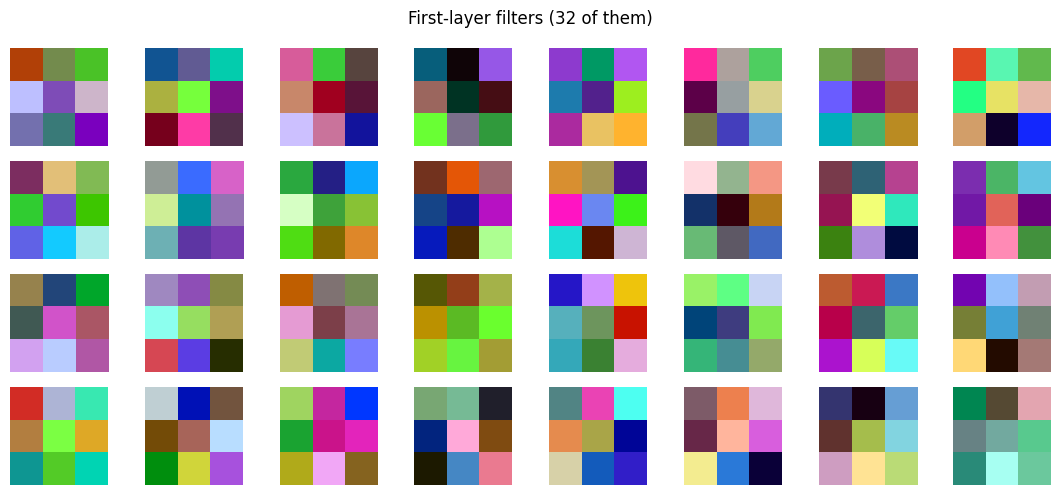

In [13]:
filters = model.conv1a.weight.detach().cpu()      # shape: [32, 3, 3, 3]
print("Conv1 filter tensor shape:", filters.shape)

# Normalise each filter to [0,1] for display
def normalise(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f

fig, axes = plt.subplots(4, 8, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(normalise(filters[i]).permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("First-layer filters (32 of them)")
plt.tight_layout()
plt.show()

## 11. Recap

You now have a real-world CNN training recipe:

| Component        | Purpose                                                          |
|------------------|------------------------------------------------------------------|
| Conv layers      | Detect spatial features with shared, sliding filters             |
| BatchNorm        | Stabilise activations, allow higher learning rates               |
| MaxPool          | Reduce spatial size, keep strongest activations                  |
| Dropout          | Regularisation — randomly zero neurons during training only      |
| Data augmentation| Free extra training data (crop, flip)                            |
| LR scheduler     | Hot start, cool finish — squeezes out extra accuracy             |
| `model.eval()`   | Tells BN/Dropout to switch to inference behaviour                |

Tomorrow we go one step further: instead of training from scratch, we **start from a pre-trained ResNet** and fine-tune it on a custom dataset — the technique that powers most real-world image classifiers.

---

### Exercises
1. Remove all `BatchNorm` layers — how much worse does training become?
2. Set `Dropout(p=0.0)` — does the gap between train/test accuracy widen?
3. Replace `StepLR` with `optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)`.
4. Add one more conv block. Does accuracy improve, or does the model overfit?
